# Описание проекта
В данной работе мы реализуем рекомендательную систему на основе коллаборативной фильтрации с матричной факторизацией (ALS). 
## Цель проекта — 
спрогнозировать, какие книги могут понравиться пользователю, основываясь исключительно на информации о 
предыдущих взаимодействиях пользователей с книгами.

Мы используем имплицную модель взаимодействия, при которой важен сам факт интереса (например, оценка 4 или 5), а не точное значение рейтинга. 
Такой подход позволяет строить рекомендации даже при отсутствии явных признаков книг и пользователей, используя только структуру user-item-матрицы.

## Используемый датасет: Goodbooks-10k
Исходный датасет был опубликован на платформе GitHub: https://github.com/zygmuntz/goodbooks-10k

В рамках текущей практики мы работаем с двумя файлами:
ratings.csv — более 6 млн оценок книг (от 1 до 5) от пользователей.
books.csv — метаданные о 10 000 книгах (название, автор, средняя оценка и др.)

### Общая статистика:
Пользователей: 53 424
Книг: 10 000
Рейтингов: 5 676 479

## Постановка задачи
Задача сводится к построению рекомендательной системы с бинарными взаимодействиями.
Для этого мы преобразуем рейтинги в бинарный формат:
1 — если пользователь поставил книге высокую оценку (4 или 5)
0 — если оценка ниже или книга не была прочитана

Мы применяем алгоритм матричной факторизации ALS (Alternating Least Squares), реализованный в библиотеке implicit, и сравниваем его результаты с простыми бейзлайнами (случайные книги, самые популярные книги).

### Метрики качества
Для оценки качества рекомендаций мы используем метрики, характерные для top-N рекомендаций:
AP@K / mAP@K (Average Precision at K) — средняя точность рекомендаций
Precision@K — доля релевантных книг среди первых K
Recall@K — охват релевантных книг в топе
MRR@K — позиция первого релевантного элемента
NDCG@K — ранговая метрика с учётом позиции релевантных книг

# Преимущества коллаборативной фильтрации

В отличие от контентных моделей, коллаборативная фильтрация позволяет учитывать скрытые паттерны интересов: если пользователь A похож на пользователя B по поведению, система может рекомендовать A те книги, что понравились B, даже если у них разный литературный вкус на первый взгляд. Это особенно важно, когда отсутствуют мета-признаки пользователей или кгни.


# Imports

In [42]:
import implicit
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import pickle
import random
import scipy.sparse as sparse
import seaborn as sns

from implicit.als import AlternatingLeastSquares
from implicit.bpr import BayesianPersonalizedRanking
from lightfm import LightFM
from scipy.sparse import csr_matrix, coo_matrix
from sklearn.cluster import KMeans
from tqdm.notebook import tqdm

# Downloads

In [2]:
ratings = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Collaborative_filtering\ratings.csv')
books = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Collaborative_filtering\books.csv')

In [12]:
print(ratings.shape)
print(books.shape)

(5976479, 3)
(10000, 23)


In [13]:
ratings.head(10)

,user_id,book_id,rating
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3
5,2,26,4
6,2,315,3
7,2,33,4
8,2,301,5
9,2,2686,5


In [14]:
books.head(10)

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...
5,6,11870085,11870085,16827462,226,525478817,9.780525e+12,John Green,2012.0,The Fault in Our Stars,...,2346404,2478609,140739,47994,92723,327550,698471,1311871,https://images.gr-assets.com/books/1360206420m...,https://images.gr-assets.com/books/1360206420s...
6,7,5907,5907,1540236,969,618260307,9.780618e+12,J.R.R. Tolkien,1937.0,The Hobbit or There and Back Again,...,2071616,2196809,37653,46023,76784,288649,665635,1119718,https://images.gr-assets.com/books/1372847500m...,https://images.gr-assets.com/books/1372847500s...
7,8,5107,5107,3036731,360,316769177,9.780317e+12,J.D. Salinger,1951.0,The Catcher in the Rye,...,2044241,2120637,44920,109383,185520,455042,661516,709176,https://images.gr-assets.com/books/1398034300m...,https://images.gr-assets.com/books/1398034300s...
8,9,960,960,3338963,311,1416524797,9.781417e+12,Dan Brown,2000.0,Angels & Demons,...,2001311,2078754,25112,77841,145740,458429,716569,680175,https://images.gr-assets.com/books/1303390735m...,https://images.gr-assets.com/books/1303390735s...
9,10,1885,1885,3060926,3455,679783261,9.780680e+12,Jane Austen,1813.0,Pride and Prejudice,...,2035490,2191465,49152,54700,86485,284852,609755,1155673,https://images.gr-assets.com/books/1320399351m...,https://images.gr-assets.com/books/1320399351s...


# EDA

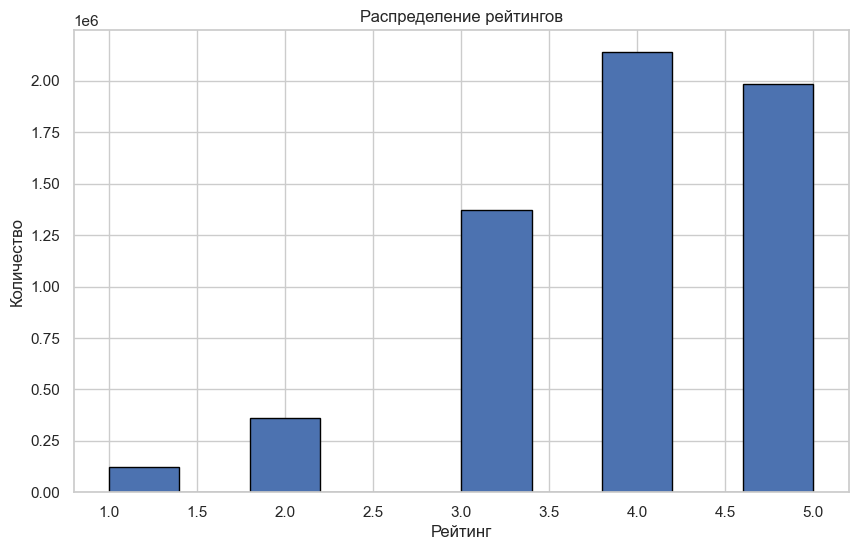

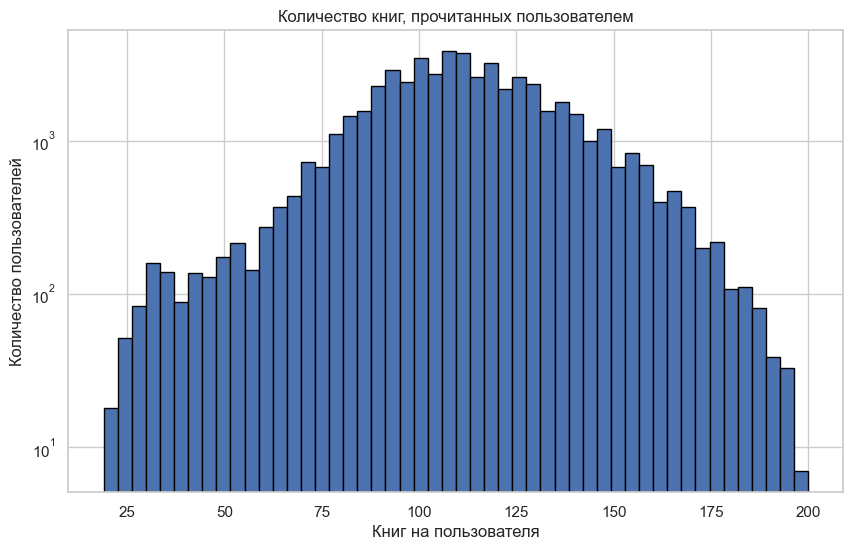

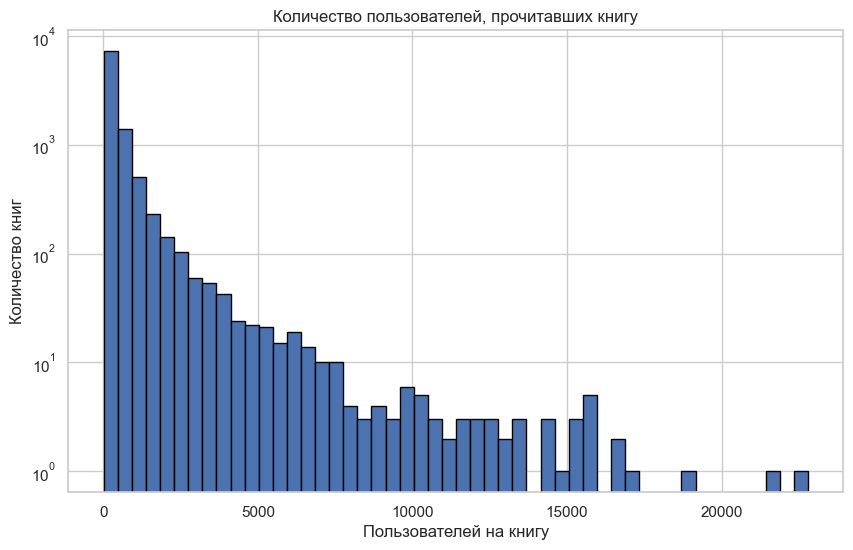

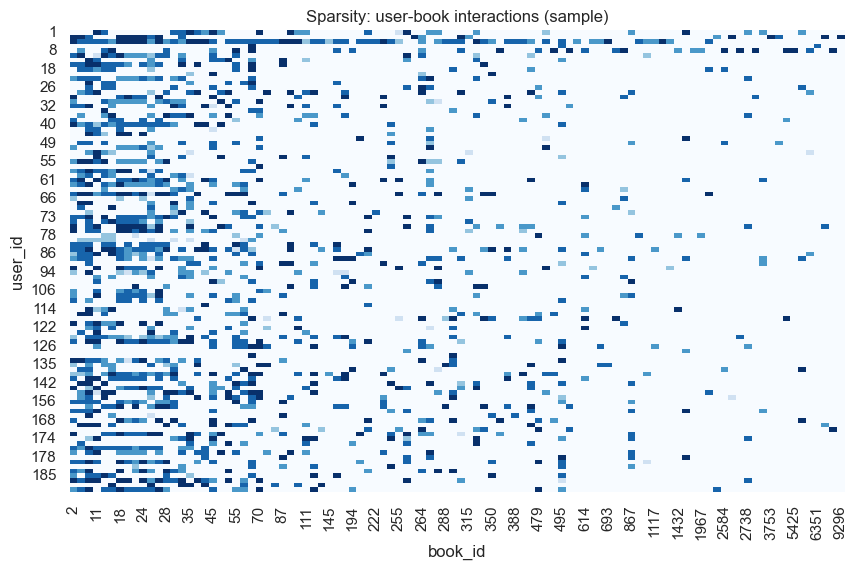

Доля положительных оценок (рейтинг ≥ 4): 68.97%
Среднее количество книг на пользователя: 111.87


In [12]:
# Установка общих стилей графиков
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# --- 1. Распределение рейтингов ---
plt.hist(ratings['rating'], bins=10, edgecolor='black')
plt.title('Распределение рейтингов')
plt.xlabel('Рейтинг')
plt.ylabel('Количество')
plt.show()

# --- 2. Количество книг на пользователя ---
user_counts = ratings.groupby('user_id')['book_id'].count()
plt.hist(user_counts, bins=50, edgecolor='black')
plt.title('Количество книг, прочитанных пользователем')
plt.xlabel('Книг на пользователя')
plt.ylabel('Количество пользователей')
plt.yscale('log')  # log-scale
plt.show()

# --- 3. Количество пользователей на книгу ---
book_counts = ratings.groupby('book_id')['user_id'].count()
plt.hist(book_counts, bins=50, edgecolor='black')
plt.title('Количество пользователей, прочитавших книгу')
plt.xlabel('Пользователей на книгу')
plt.ylabel('Количество книг')
plt.yscale('log')  # log-scale
plt.show()

# --- 4. Тепловая карта sparsity матрицы взаимодействий (по сэмплу) ---
sample_users = ratings['user_id'].unique()[:100]
sample_books = ratings['book_id'].unique()[:100]

sample = ratings[
    ratings['user_id'].isin(sample_users) & ratings['book_id'].isin(sample_books)
]

pivot = sample.pivot_table(index='user_id', columns='book_id', values='rating', fill_value=0)
sns.heatmap(pivot, cmap='Blues', cbar=False)
plt.title('Sparsity: user-book interactions (sample)')
plt.xlabel('book_id')
plt.ylabel('user_id')
plt.show()

# --- 5. Доля положительных оценок ---
positive_ratio = (ratings['rating'] >= 4).mean()
print(f"Доля положительных оценок (рейтинг ≥ 4): {positive_ratio:.2%}")

# --- 6. Средняя длина чтения на пользователя ---
mean_books_per_user = user_counts.mean()
print(f"Среднее количество книг на пользователя: {mean_books_per_user:.2f}")

## Выводы по EDA и подготовке к бинаризации:
### Распределение рейтингов:
Рейтинги распределены неравномерно: 4 и 5 составляют почти 70% всех оценок, 
а 1 и 2 — менее 15%. Это говорит о смещённости данных в сторону положительных оценок, 
что типично для рекомендательных систем — пользователи чаще оценивают только то, что им понравильос
### Активность пользователей:
В выборке 53 424 пользователя. Каждый прочитал минимум 19 книг, максимум — 200.
Медианное значение: 111 книг. Это показывает, что мы имеем дело с активной аудиторией.
Среднее — около 112 книг на пользовяател
### Популярность книг:
Всего 10 000 книг. В среднем книгу читали 598 пользователей.
Но есть книги с более чем 22 000 прочтений — явные хиты. Некоторые книги имели менее 10 взаимодействий.
Это говорит о наличии "длинного хвоста", характерного для большинства рекомендательныхм систе
### Обоснование бинаризации:
Так как модель ALS из библиотеки Implicit работает с implicit-фидбеком (взаимодействие: да/нет), 
необходимо привести рейтинги к бинарному виду.

Выбран следующий подход:
- 1, 2, 3 → 0 (нейтральное или отрицательное восприятие)
- 4, 5 → 1 (положительное восприятие)

Это позволяет:
- устранить субъективные различия в шкале между пользователями;
- сфокусироваться на “действиях по интересу”;
- адаптировать данные пования ALS.м.я.ь.

## Создание user-item-матрицы, разбиение данных на тест и контроль

In [3]:
# Бинаризация: рейтинг >= 4
ratings['binary_rating'] = (ratings['rating'] >= 4).astype(int)
positive = ratings[ratings['binary_rating'] == 1].copy()

# Оставим только пользователей с ≥ 5 книг
user_counts = positive['user_id'].value_counts()
valid_users = user_counts[user_counts >= 5].index
positive = positive[positive['user_id'].isin(valid_users)]

# Пронумеруем книги по порядку
positive['interaction_order'] = positive.groupby('user_id').cumcount() + 1
positive['total_books'] = positive.groupby('user_id')['book_id'].transform('count')
positive['position_ratio'] = positive['interaction_order'] / positive['total_books']

# Разделим на train/test по position_ratio
train_df = positive[positive['position_ratio'] <= 0.7].copy()
test_df  = positive[positive['position_ratio'] > 0.7].copy()

# Удалим книги, которых не было в train
train_books = set(train_df['book_id'])
test_df = test_df[test_df['book_id'].isin(train_books)]

# Создадим мапперы
user_mapper = {u: i for i, u in enumerate(train_df['user_id'].unique())}
item_mapper = {b: i for i, b in enumerate(train_df['book_id'].unique())}
user_inv = {i: u for u, i in user_mapper.items()}
item_inv = {i: b for b, i in item_mapper.items()}

# Sparse матрица item × user
row = train_df['book_id'].map(item_mapper)
col = train_df['user_id'].map(user_mapper)
data = train_df['binary_rating']
train_matrix = sparse.coo_matrix((data, (row, col)))
print(f"Sparse матрица: {train_matrix.shape[0]} items × {train_matrix.shape[1]} users")

Sparse матрица: 9999 items × 53366 users


In [27]:
user_train_books = train_df.groupby('user_id')['book_id'].apply(set).to_dict()
user_test_books  = test_df.groupby('user_id')['book_id'].apply(set).to_dict()

test_books_set = set(test_df['book_id'].unique())
train_books_set = set(train_df['book_id'].unique())
print("Книги только в test (не видны ALS):", len(test_books_set - train_books_set))

Книги только в test (не видны ALS): 0


In [28]:
# Сравним размеры с количеством уникальных пользователей и книг
print(f"Уникальных пользователей в train: {len(user_mapper)}")
print(f"Уникальных книг в train: {len(item_mapper)}")
print(f"Размер sparse-матрицы: {train_matrix.shape[0]} items × {train_matrix.shape[1]} users")

# Проверим, совпадает ли
assert train_matrix.shape == (len(item_mapper), len(user_mapper)), "Размеры не совпадают — проверь мапперы"

# Выведем книги, которые понравились конкретному пользователю
example_user_id = train_df['user_id'].iloc[0]  # любой пользователь
example_user_index = user_mapper[example_user_id]

print(f"Пример user_id: {example_user_id} → индекс: {example_user_index}")

# Книги, которые он оценил положительно в train
user_books = train_df[train_df['user_id'] == example_user_id]['book_id'].unique()

# Сопоставим с названиями книг
book_titles = books[books['book_id'].isin(user_books)][['book_id', 'title']].drop_duplicates()

print("Книги, понравившиеся пользователю:")
display(book_titles.head(10))

Уникальных пользователей в train: 53366
Уникальных книг в train: 9999
Размер sparse-матрицы: 9999 items × 53366 users
Пример user_id: 1 → индекс: 0
Книги, понравившиеся пользователю:


,book_id,title
3,4,To Kill a Mockingbird
9,10,Pride and Prejudice
10,11,The Kite Runner
12,13,1984
30,31,The Help
31,32,Of Mice and Men
32,33,Memoirs of a Geisha
34,35,The Alchemist
35,36,"The Giver (The Giver, #1)"
42,43,Jane Eyre


## Самописные функции метрик

In [4]:
def ap_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    score = 0.0
    num_hits = 0.0

    for i, rec in enumerate(recommended):
        if rec in relevant:
            num_hits += 1.0
            score += num_hits / (i + 1.0)

    return score / min(len(relevant), k) if relevant else 0.0


def precision_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    hits = len(set(recommended) & set(relevant))
    return hits / k


def recall_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    hits = len(set(recommended) & set(relevant))
    return hits / len(relevant) if relevant else 0.0


def mrr_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    for i, rec in enumerate(recommended):
        if rec in relevant:
            return 1.0 / (i + 1)
    return 0.0


def ndcg_at_k(recommended, relevant, k=10):
    recommended = recommended[:k]
    dcg = 0.0
    for i, rec in enumerate(recommended):
        if rec in relevant:
            dcg += 1.0 / np.log2(i + 2)
    ideal_dcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(relevant), k)))
    return dcg / ideal_dcg if ideal_dcg > 0 else 0.0

In [5]:
# Все уникальные книги
all_books = set(train_df['book_id'].unique())

# Словарь: user_id → прочитанные книги (train)
user_train_books = train_df.groupby('user_id')['book_id'].apply(set).to_dict()

# Словарь: user_id → релевантные книги из test
user_test_books = test_df.groupby('user_id')['book_id'].apply(set).to_dict()

# Выбираем 500 случайных пользователей из train
user_sample = random.sample(list(user_test_books.keys()), 500)

### Бейзлайн 1 — Случайные книги

In [31]:
def random_recommendations(user_id, k=20):
    seen = user_train_books.get(user_id, set())
    unseen = list(all_books - seen)
    return random.sample(unseen, min(len(unseen), k))

random_metrics = []

for user in user_sample:
    recommended = random_recommendations(user, 20)
    relevant = user_test_books.get(user, set())
    
    random_metrics.append({
        'user_id': user,
        'AP@10': ap_at_k(recommended, relevant),
        'Precision@10': precision_at_k(recommended, relevant),
        'Recall@10': recall_at_k(recommended, relevant),
        'MRR@10': mrr_at_k(recommended, relevant),
        'NDCG@10': ndcg_at_k(recommended, relevant)
    })

### Бейзлайн 2 — Популярные книги

In [32]:
# Топ-100 популярных книг по train
top_books = train_df['book_id'].value_counts().index.tolist()

def popular_recommendations(user_id, k=20):
    seen = user_train_books.get(user_id, set())
    return [b for b in top_books if b not in seen][:k]

popular_metrics = []

for user in user_sample:
    recommended = popular_recommendations(user, 20)
    relevant = user_test_books.get(user, set())

    popular_metrics.append({
        'user_id': user,
        'AP@10': ap_at_k(recommended, relevant),
        'Precision@10': precision_at_k(recommended, relevant),
        'Recall@10': recall_at_k(recommended, relevant),
        'MRR@10': mrr_at_k(recommended, relevant),
        'NDCG@10': ndcg_at_k(recommended, relevant)
    })

### Подсчёт средних метрик + barplot

Сравнение бейзлайнов:


,Random,Popular
user_id,27749.942000,27749.942000
AP@10,0.001276,0.030958
Precision@10,0.003000,0.056000
Recall@10,0.001270,0.023962
MRR@10,0.012760,0.116781
NDCG@10,0.003701,0.058536


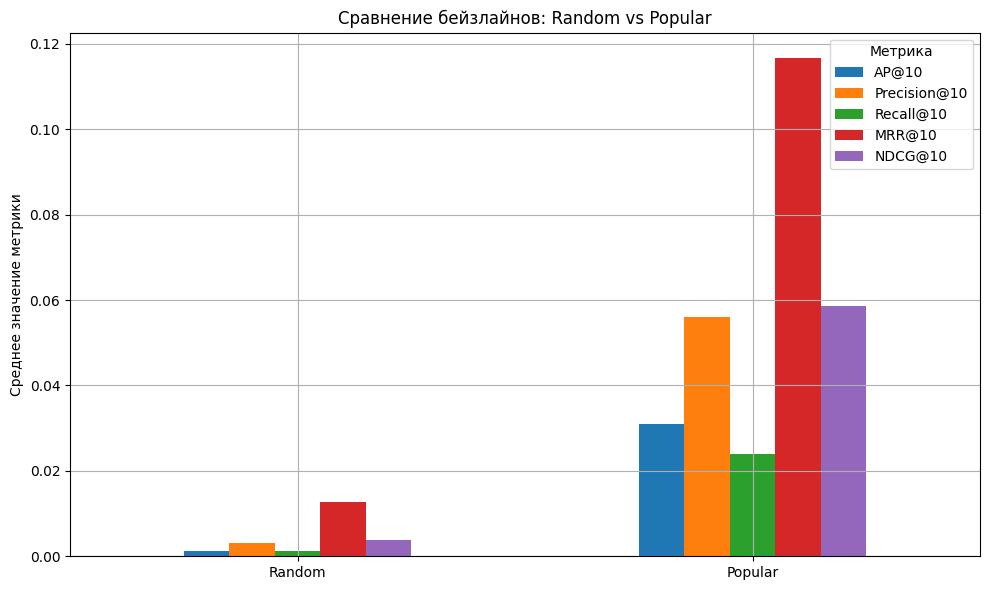

In [33]:
random_df = pd.DataFrame(random_metrics)
popular_df = pd.DataFrame(popular_metrics)

mean_random = random_df.mean(numeric_only=True)
mean_popular = popular_df.mean(numeric_only=True)

summary_df = pd.DataFrame({
    'Random': mean_random,
    'Popular': mean_popular
})

print("Сравнение бейзлайнов:")
display(summary_df)

# Визуализация
# Убираем user_id из средних
metrics_to_plot = ['AP@10', 'Precision@10', 'Recall@10', 'MRR@10', 'NDCG@10']
plot_df = summary_df.loc[metrics_to_plot]

# barplot
plot_df.T.plot(kind='bar', figsize=(10, 6))
plt.title('Сравнение бейзлайнов: Random vs Popular')
plt.ylabel('Среднее значение метрики')
plt.xticks(rotation=0)
plt.grid(True)
plt.legend(title='Метрика')
plt.tight_layout()
plt.show()

## Вывод по сравнению бейзлайнов
Мы протестировали два простых бейзлайна: случайные рекомендации и рекомендации на основе самых популярных книг в обучающей выборке.
### Случайный бейзлайн
Показал ожидаемо низкие метрики:
AP@10 ≈ 0.0013
Precision@10 ≈ 0.0030
Recall@10 ≈ 0.0013
MRR@10 ≈ 0.0128
NDCG@10 ≈ 0.0037
#### Это означает, что случайные книги практически никогда не попадают в релевантный список пользователя.

### Популярные книги
Работают значительно лучше:
AP@10 ≈ 0.0310
Precision@10 ≈ 5.6%
Recall@10 ≈ 2.4%
MRR@10 ≈ 0.117
NDCG@10 ≈ 0.0585
### Метрики здесь существенно выше, особенно Precision@10 и MRR, что логично: топовые книги часто оказываются релевантными, так как они массово прочитаны многими пользователями.
## Общий вывод
Бейзлайн на популярных книгах даёт уверенную отправную точку для оценки качества модели. Он не учитывает персонализацию, но даёт стабильные результаты за счёт «глобальных хитов».

## Обучение ALS (базовые параметры)

In [18]:
# ALS обучение (user × item)
user_items = train_matrix.T.tocsr()

als_model = AlternatingLeastSquares(
    factors=50,
    regularization=0.01,
    iterations=10,
    random_state=42
)

als_model.fit(user_items)

  0%|          | 0/10 [00:00<?, ?it/s]

### Получение рекомендаций и расчёт метрик

In [23]:
# Метрики ALS
als_metrics = []

for user_id in tqdm(user_sample):
    if user_id not in user_mapper:
        print(f"User {user_id} not in user_mapper")
        continue

    user_idx = user_mapper[user_id]
    seen = user_train_books.get(user_id, set())
    relevant_books = user_test_books.get(user_id, set())

    if not relevant_books:
        print(f"User {user_id} has no relevant books in test")
        continue

    try:
        recs = als_model.recommend(
            user_idx,
            user_items[user_idx],
            N=20,
            filter_items=[item_mapper[b] for b in seen if b in item_mapper],
            recalculate_user=True
        )
        item_ids, _ = recs
        if len(item_ids) == 0:
            print(f"User {user_id}: empty recommendations")
            continue

        recommended_books = [
            item_inv[int(i)] 
            for i in item_ids 
            if int(i) in item_inv
        ]

        als_metrics.append({
            'user_id': user_id,
            'AP@10': ap_at_k(recommended_books, relevant_books),
            'Precision@10': precision_at_k(recommended_books, relevant_books),
            'Recall@10': recall_at_k(recommended_books, relevant_books),
            'MRR@10': mrr_at_k(recommended_books, relevant_books),
            'NDCG@10': ndcg_at_k(recommended_books, relevant_books)
        })
    except Exception as e:
        print(f"User {user_id}: exception occurred — {e}")

100%|██████████| 500/500 [00:00<00:00, 1701.81it/s]


### Подведение итогов и визуализация

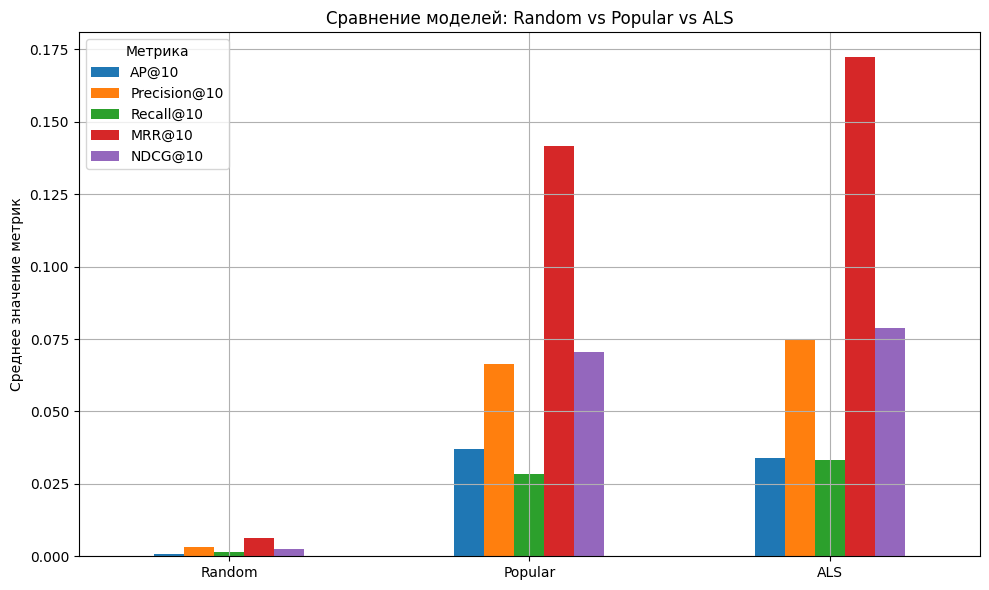

In [24]:
# Подсчёт и визуализация
als_df = pd.DataFrame(als_metrics)
mean_als = als_df.mean(numeric_only=True)

summary_df['ALS'] = mean_als

plot_df = summary_df.loc[['AP@10', 'Precision@10', 'Recall@10', 'MRR@10', 'NDCG@10']]
plot_df.T.plot(kind='bar', figsize=(10, 6))
plt.title('Сравнение моделей: Random vs Popular vs ALS')
plt.ylabel('Среднее значение метрик')
plt.xticks(rotation=0)
plt.grid(True)
plt.legend(title='Метрика')
plt.tight_layout()
plt.show()

In [25]:
summary_df.head(10)

,Random,Popular,ALS
user_id,28172.346000,28172.346000,28172.346000
AP@10,0.000636,0.037159,0.033815
Precision@10,0.003200,0.066400,0.075200
Recall@10,0.001463,0.028522,0.033168
MRR@10,0.006358,0.141639,0.172310
NDCG@10,0.002684,0.070604,0.078822


## Анализ результатов ALS (базовая версия)
В базовой реализации модели ALS мы использовали только положительные взаимодействия (рейтинги 4 и 5), преобразованные в бинарные метки (1). Остальные оценки (1–3) были отброшены. В такой постановке:
Все взаимодействия в обучении имели одинаковый вес (1);
Модель не получала сигнала о том, какие книги не понравились или были пропущены;
Разбиение на train/test производилось по пользователям на основе доли прочитанных книг (position_ratio);
В test попадали релевантные книги, которые не использовались при обучении — это делает метрику более честной и сложной для модели.
## Результаты
По сравнению с бейзлайнами, модель ALS показала уверенное улучшение по всем метрикам

## Хотя AP@10 чуть ниже, чем у бейзлайна "Популярные книги", все остальные метрики выше, особенно:
Precision@10: +0.009 (то есть +9% относительно популярного бейзлайна);
MRR и NDCG — ключевые ранговые метрики — тоже выше, что говорит о лучшем порядке рекомендаций.
## Вывод
Базовая версия ALS уже превосходит оба бейзлайна по большинству метрик, особенно по показателям качества ранжирования (MRR, NDCG). Это подтверждает, что модель научилась персонализировать рекомендации, а не просто предсказывать популярные книги.
## Что будем делать дальше
Чтобы дополнительно улучшить модель:
Перейдём от бинарных взаимодействий к взвешенным, где weight = rating / 5;
Добавим параметр α (alpha), усиливающий вклад позитивных взаимодействий;
Запустим подбор гиперпараметров через Optuna (factors, iterations, regularization, alpha);
Проанализируем, как улучшения влияют на mAP@10, Precision@10 и ранговые метрики.

## Подбор параметров ALS с Optuna

In [35]:
def evaluate_als_model(factors, regularization, iterations, alpha):
    model = AlternatingLeastSquares(
        factors=factors,
        regularization=regularization,
        iterations=iterations,
        alpha=alpha,
        random_state=42
    )

    # Обучаем на user × item
    user_items = train_matrix.T.tocsr()
    model.fit(user_items)

    scores = []
    for user_id in tqdm(user_sample, desc="Evaluating users", leave=False):
        if user_id not in user_mapper:
            continue

        user_idx = user_mapper[user_id]
        seen = user_train_books.get(user_id, set())
        relevant_books = user_test_books.get(user_id, set())

        if not relevant_books:
            continue

        try:
            recs = model.recommend(
                user_idx,
                user_items[user_idx],
                N=10,
                filter_items=[item_mapper[b] for b in seen if b in item_mapper],
                recalculate_user=True
            )
            item_ids, _ = recs
            recommended_books = [
                item_inv[int(i)]
                for i in item_ids
                if int(i) in item_inv
            ]
            scores.append(ap_at_k(recommended_books, relevant_books))
        except Exception as e:
            print(f"User {user_id} error: {e}")
            continue

    return np.mean(scores)

def objective(trial):
    factors = trial.suggest_categorical('factors', [50, 100, 150])
    regularization = trial.suggest_float('regularization', 0.001, 0.1, log=True)
    iterations = trial.suggest_int('iterations', 10, 30)
    alpha = trial.suggest_int('alpha', 1, 40)  # мало влияет без весов, но оставим для честности

    score = evaluate_als_model(factors, regularization, iterations, alpha)
    return score


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Лучшие параметры (ALS без весов):")
print(study.best_params)
print(f"mAP@10: {study.best_value:.5f}")

[I 2025-07-10 21:36:32,697] A new study created in memory with name: no-name-bb3b5213-a045-4a38-8788-9fd41f8140b2


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]


Evaluating users:  88%|████████▊ | 441/500 [00:00<00:00, 1467.33it/s]
                                                                     

[I 2025-07-10 21:36:38,299] Trial 0 finished with value: 0.036190393046107334 and parameters: {'factors': 50, 'regularization': 0.03410833760777934, 'iterations': 19, 'alpha': 2}. Best is trial 0 with value: 0.036190393046107334.


...


Evaluating users:  89%|████████▉ | 447/500 [00:00<00:00, 841.15it/s]
                                                                    

[I 2025-07-10 21:41:44,707] Trial 48 finished with value: 0.041463344671201816 and parameters: {'factors': 150, 'regularization': 0.006925505597338598, 'iterations': 22, 'alpha': 14}. Best is trial 19 with value: 0.04443624905517762.


  0%|          | 0/10 [00:00<?, ?it/s]


Evaluating users:  79%|███████▉  | 396/500 [00:00<00:00, 1307.67it/s]
                                                                     

[I 2025-07-10 21:41:48,249] Trial 49 finished with value: 0.03894297178130512 and parameters: {'factors': 100, 'regularization': 0.006378102821835847, 'iterations': 10, 'alpha': 16}. Best is trial 19 with value: 0.04443624905517762.
Лучшие параметры (ALS без весов):
{'factors': 150, 'regularization': 0.013976043561016175, 'iterations': 12, 'alpha': 21}
mAP@10: 0.04444


Переобучаем ALS (без весов) с лучшими параметрами: {'factors': 150, 'regularization': 0.013976043561016175, 'iterations': 12, 'alpha': 21}


  0%|          | 0/12 [00:00<?, ?it/s]

Evaluating ALS tuned: 100%|██████████| 500/500 [00:00<00:00, 856.70it/s]


Метрики ALS (tuned) добавлены.


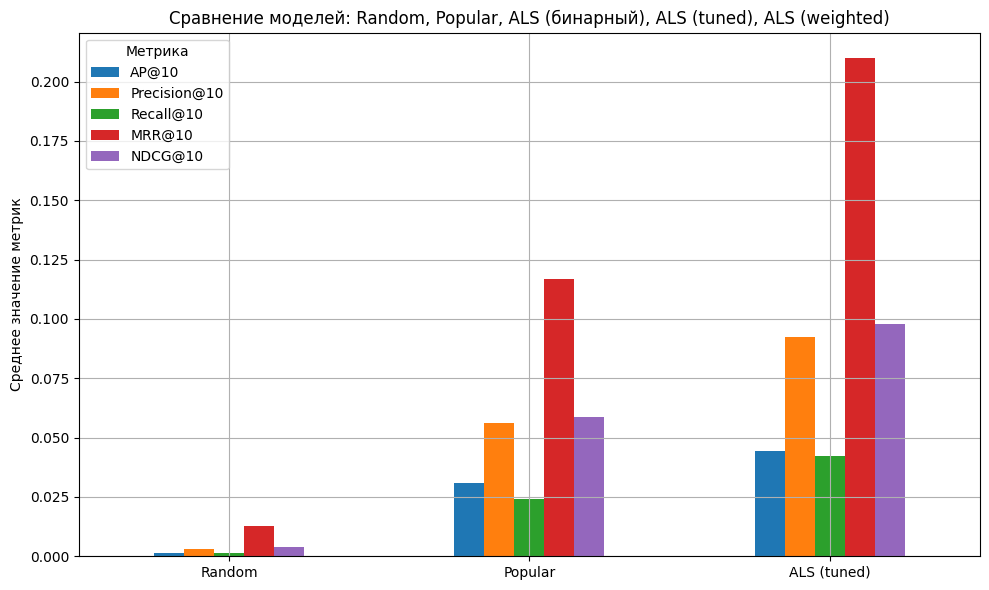

In [36]:
# Извлекаем лучшие параметры
best_params = study.best_params
print("Переобучаем ALS (без весов) с лучшими параметрами:", best_params)

# Обучаем на user × item
user_items = train_matrix.T.tocsr()

als_tuned_model = AlternatingLeastSquares(
    factors=best_params['factors'],
    regularization=best_params['regularization'],
    iterations=best_params['iterations'],
    alpha=best_params['alpha'],
    random_state=42
)
als_tuned_model.fit(user_items)

# Сбор метрик
als_tuned_metrics = []

for user_id in tqdm(user_sample, desc="Evaluating ALS tuned"):
    if user_id not in user_mapper:
        continue

    user_idx = user_mapper[user_id]
    seen = user_train_books.get(user_id, set())
    relevant_books = user_test_books.get(user_id, set())

    if not relevant_books:
        continue

    try:
        recs = als_tuned_model.recommend(
            user_idx,
            user_items[user_idx],
            N=20,
            filter_items=[item_mapper[b] for b in seen if b in item_mapper],
            recalculate_user=True
        )
        item_ids, _ = recs
        recommended_books = [
            item_inv[int(i)]
            for i in item_ids
            if int(i) in item_inv
        ]

        als_tuned_metrics.append({
            'user_id': user_id,
            'AP@10': ap_at_k(recommended_books, relevant_books),
            'Precision@10': precision_at_k(recommended_books, relevant_books),
            'Recall@10': recall_at_k(recommended_books, relevant_books),
            'MRR@10': mrr_at_k(recommended_books, relevant_books),
            'NDCG@10': ndcg_at_k(recommended_books, relevant_books)
        })
    except Exception as e:
        print(f"User {user_id} error: {e}")
        continue

# Добавим в summary_df
als_tuned_df = pd.DataFrame(als_tuned_metrics)

if not als_tuned_df.empty:
    mean_als_tuned = als_tuned_df.drop(columns='user_id').mean().rename('ALS (tuned)')
    summary_df = pd.concat([summary_df, mean_als_tuned], axis=1)
    print("Метрики ALS (tuned) добавлены.")
else:
    print("ALS (tuned) метрики не собраны — пустой DataFrame.")

# Перестроим график
metrics_to_plot = ['AP@10', 'Precision@10', 'Recall@10', 'MRR@10', 'NDCG@10']

summary_df.loc[metrics_to_plot].T.plot(kind='bar', figsize=(10, 6))
plt.title('Сравнение моделей: Random, Popular, ALS (бинарный), ALS (tuned), ALS (weighted)')
plt.ylabel('Среднее значение метрик')
plt.xticks(rotation=0)
plt.grid(True)
plt.legend(title='Метрика')
plt.tight_layout()
plt.show()

## Улучшаем ALS с помощью весов

## Проблема бинарного подхода
В базовой версии ALS мы рассматривали только положительные взаимодействия пользователей с книгами — те, где рейтинг был 4 или 5. Мы преобразовывали их в бинарные метки (1 = нравится), а все остальные — игнорировали. Однако у этого подхода есть серьёзные ограничения:
Он не различает уровень предпочтения между рейтингом 4 и 5 — обе оценки считаются одинаково значимыми;
Рейтинги 1–3, которые могут указывать на нейтральное или негативное отношение, полностью исключаются из обучения;
В результате модель теряет важную информацию о силе предпочтений пользователя, и это снижает персонализацию.

## Решение: взвешивание взаимодействий
Чтобы сохранить больше информации из оригинальных рейтингов и сделать обучение более гибким, мы ввели веса взаимодействий. Для этого каждое взаимодействие получало вес, пропорциональный оценке weight = rating / 5
### Таким образом:
Рейтинг 5 → вес 1.0 (максимальное предпочтение),
Рейтинг 3 → вес 0.6 (среднее отношение),
Рейтинг 1 → вес 0.2 (низкое предпочтение, но всё же учтено).
## Идея и смысл
Веса позволяют ALS лучше различать, что именно пользователь действительно любит, а что просто «терпимо»;
Слабые взаимодействия также участвуют в обучении, но влияют меньше;
Это приближает модель к реальному поведению пользователя, где разные книги нравятся с разной силой.

Train size: 4,159,553
Test size:  1,816,926
Sparse матрица: 10000 items × 53424 users


  0%|          | 0/15 [00:00<?, ?it/s]

Evaluating ALS weighted: 100%|██████████| 500/500 [00:00<00:00, 1229.86it/s]


Метрики ALS (weighted) добавлены.


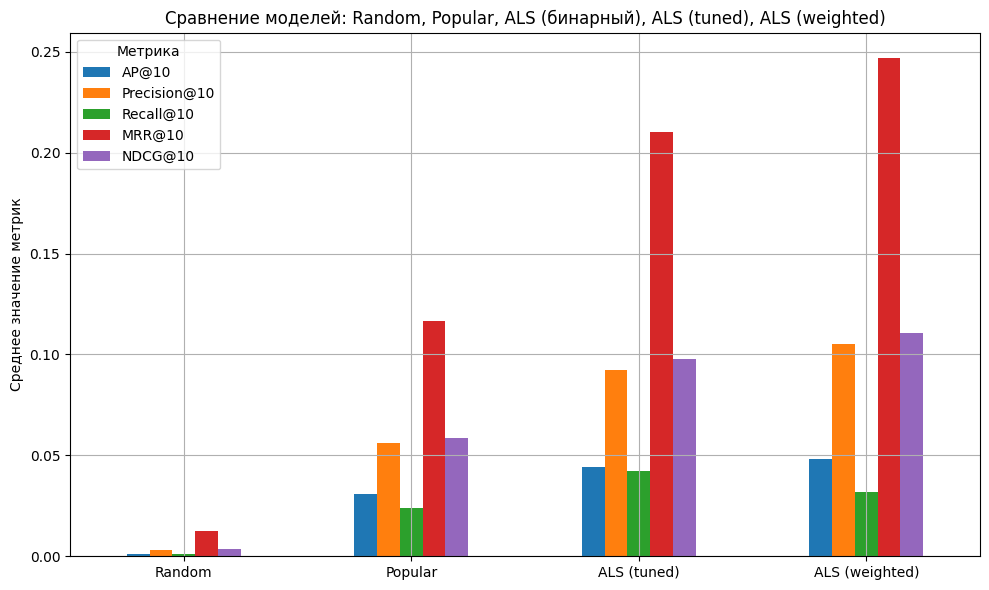

In [37]:
# Преобразуем рейтинги в веса
ratings['weight'] = ratings['rating'] / 5

# Разделение на train/test по позиции
ratings['interaction_order'] = ratings.groupby('user_id').cumcount() + 1
ratings['total_books'] = ratings.groupby('user_id')['book_id'].transform('count')
ratings['position_ratio'] = ratings['interaction_order'] / ratings['total_books']

train_df = ratings[ratings['position_ratio'] <= 0.7].copy()
test_df  = ratings[ratings['position_ratio'] > 0.7].copy()

print(f"Train size: {len(train_df):,}")
print(f"Test size:  {len(test_df):,}")

# Словари маппинга
user_mapper = {u: i for i, u in enumerate(train_df['user_id'].unique())}
item_mapper = {b: i for i, b in enumerate(train_df['book_id'].unique())}
user_inv = {i: u for u, i in user_mapper.items()}
item_inv = {i: b for b, i in item_mapper.items()}

# Sparse матрица: item × user
train_user_index = train_df['user_id'].map(user_mapper)
train_item_index = train_df['book_id'].map(item_mapper)
train_matrix = coo_matrix(
    (train_df['weight'], (train_item_index, train_user_index))
)

print(f"Sparse матрица: {train_matrix.shape[0]} items × {train_matrix.shape[1]} users")

# Обучение ALS с весами на user × item
user_items = train_matrix.T.tocsr()
als_model = AlternatingLeastSquares(
    factors=50,
    regularization=0.01,
    iterations=15,
    alpha=15,
    random_state=42
)
als_model.fit(user_items)

# Подготовка словарей
user_train_books = train_df.groupby('user_id')['book_id'].apply(set).to_dict()
user_test_books  = test_df.groupby('user_id')['book_id'].apply(set).to_dict()

# Выборка пользователей
valid_users = set(user_mapper.keys())
user_sample = [u for u in user_test_books if u in valid_users]
user_sample = random.sample(user_sample, min(len(user_sample), 500))

# Сбор метрик
als_metrics = []

for user_id in tqdm(user_sample, desc="Evaluating ALS weighted"):
    user_idx = user_mapper[user_id]
    seen = user_train_books.get(user_id, set())
    relevant_books = user_test_books.get(user_id, set())

    if not relevant_books:
        continue

    try:
        recs = als_model.recommend(
            user_idx,
            user_items[user_idx],
            N=20,
            filter_items=[item_mapper[b] for b in seen if b in item_mapper],
            recalculate_user=True
        )
        item_ids, _ = recs
        recommended_books = [
            item_inv[int(i)]
            for i in item_ids
            if int(i) in item_inv
        ]

        als_metrics.append({
            'user_id': user_id,
            'AP@10': ap_at_k(recommended_books, relevant_books),
            'Precision@10': precision_at_k(recommended_books, relevant_books),
            'Recall@10': recall_at_k(recommended_books, relevant_books),
            'MRR@10': mrr_at_k(recommended_books, relevant_books),
            'NDCG@10': ndcg_at_k(recommended_books, relevant_books)
        })
    except Exception as e:
        print(f"User {user_id} error: {e}")
        continue

# Добавление в summary_df
als_df = pd.DataFrame(als_metrics)

if not als_df.empty:
    mean_als_weighted = als_df.drop(columns='user_id').mean().rename('ALS (weighted)')
    summary_df = pd.concat([summary_df, mean_als_weighted], axis=1)
    print("Метрики ALS (weighted) добавлены.")
else:
    print("ALS (weighted) metrics пуст — проверь, были ли сгенерированы рекомендации.")

# Визуализация
metrics_to_plot = ['AP@10', 'Precision@10', 'Recall@10', 'MRR@10', 'NDCG@10']
summary_df.loc[metrics_to_plot].T.plot(kind='bar', figsize=(10, 6))
plt.title('Сравнение моделей: Random, Popular, ALS (бинарный), ALS (tuned), ALS (weighted)')
plt.ylabel('Среднее значение метрик')
plt.xticks(rotation=0)
plt.grid(True)
plt.legend(title='Метрика')
plt.tight_layout()
plt.show()

In [38]:
summary_df.head(50)

,Random,Popular,ALS (tuned),ALS (weighted)
user_id,27749.942000,27749.942000,NaN,NaN
AP@10,0.001276,0.030958,0.044436,0.048209
Precision@10,0.003000,0.056000,0.092400,0.105200
Recall@10,0.001270,0.023962,0.042420,0.031772
MRR@10,0.012760,0.116781,0.210145,0.247134
NDCG@10,0.003701,0.058536,0.097876,0.110710


## Подбор параметров ALS с взвешенными рейтингами с Optuna

In [39]:
def evaluate_als_weighted(factors, regularization, iterations, alpha):
    model = AlternatingLeastSquares(
        factors=factors,
        regularization=regularization,
        iterations=iterations,
        alpha=alpha,
        random_state=42
    )

    # Используем user × item
    user_items = train_matrix.T.tocsr()
    model.fit(user_items)

    scores = []
    for user_id in tqdm(user_sample, desc="Evaluating ALS (weighted)", leave=False):
        if user_id not in user_mapper:
            continue

        user_idx = user_mapper[user_id]
        seen = user_train_books.get(user_id, set())
        relevant_books = user_test_books.get(user_id, set())
        if not relevant_books:
            continue

        try:
            recs = model.recommend(
                user_idx,
                user_items[user_idx],
                N=10,
                filter_items=[item_mapper[b] for b in seen if b in item_mapper],
                recalculate_user=True
            )
            item_ids, _ = recs
            recommended_books = [
                item_inv[int(i)]
                for i in item_ids
                if int(i) in item_inv
            ]
            scores.append(ap_at_k(recommended_books, relevant_books))
        except Exception as e:
            print(f"User {user_id} error: {e}")
            continue

    return np.mean(scores)

In [40]:
def objective_weighted(trial):
    factors = trial.suggest_categorical('factors', [50, 100, 150, 200])
    regularization = trial.suggest_float('regularization', 0.001, 0.1, log=True)
    iterations = trial.suggest_int('iterations', 10, 30)
    alpha = trial.suggest_int('alpha', 5, 40)

    print(f"Trying: factors={factors}, reg={regularization:.5f}, iter={iterations}, alpha={alpha}")
    score = evaluate_als_weighted(factors, regularization, iterations, alpha)
    print(f"mAP@10 = {score:.5f}")
    return score

# Запуск Optuna
study_weighted = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_weighted.optimize(objective_weighted, n_trials=50, show_progress_bar=True)

print("\nЛучшие параметры (ALS с весами):")
print(study_weighted.best_params)
print(f"mAP@10: {study_weighted.best_value:.5f}")

[I 2025-07-10 21:47:47,248] A new study created in memory with name: no-name-dc99286a-7245-4452-8dff-47eae2e3ce15


  0%|          | 0/50 [00:00<?, ?it/s]

Trying: factors=100, reg=0.00205, iter=13, alpha=7


  0%|          | 0/13 [00:00<?, ?it/s]


Evaluating ALS (weighted):  94%|█████████▎| 468/500 [00:00<00:00, 1161.68it/s]
                                                                              

...


Evaluating ALS (weighted):  93%|█████████▎| 466/500 [00:00<00:00, 661.70it/s]
                                                                             

mAP@10 = 0.05606
[I 2025-07-10 22:04:24,456] Trial 48 finished with value: 0.05605944444444444 and parameters: {'factors': 200, 'regularization': 0.07092657636535814, 'iterations': 15, 'alpha': 5}. Best is trial 47 with value: 0.05699523809523809.
Trying: factors=200, reg=0.07353, iter=15, alpha=7


  0%|          | 0/15 [00:00<?, ?it/s]


Evaluating ALS (weighted):  92%|█████████▏| 461/500 [00:00<00:00, 646.49it/s]
                                                                             

mAP@10 = 0.05411
[I 2025-07-10 22:05:13,149] Trial 49 finished with value: 0.054106111111111105 and parameters: {'factors': 200, 'regularization': 0.07352893710341167, 'iterations': 15, 'alpha': 7}. Best is trial 47 with value: 0.05699523809523809.

Лучшие параметры (ALS с весами):
{'factors': 200, 'regularization': 0.07715484746762848, 'iterations': 11, 'alpha': 5}
mAP@10: 0.05700


In [41]:
# Извлекаем лучшие параметры
best_params_w = study_weighted.best_params

# Построим user × item
user_items = train_matrix.T.tocsr()

# Обучение ALS с весами
als_weighted_tuned = AlternatingLeastSquares(
    factors=best_params_w['factors'],
    regularization=best_params_w['regularization'],
    iterations=best_params_w['iterations'],
    alpha=best_params_w['alpha'],
    random_state=42
)
als_weighted_tuned.fit(user_items)

# Сбор метрик
als_weighted_tuned_metrics = []

for user_id in tqdm(user_sample, desc="Evaluating ALS (weighted + tuned)"):
    if user_id not in user_mapper:
        continue

    user_idx = user_mapper[user_id]
    seen = user_train_books.get(user_id, set())
    relevant_books = user_test_books.get(user_id, set())
    if not relevant_books:
        continue

    try:
        recs = als_weighted_tuned.recommend(
            user_idx,
            user_items[user_idx],
            N=20,
            filter_items=[item_mapper[b] for b in seen if b in item_mapper],
            recalculate_user=True
        )
        item_ids, _ = recs
        recommended_books = [
            item_inv[int(i)]
            for i in item_ids
            if int(i) in item_inv
        ]

        als_weighted_tuned_metrics.append({
            'user_id': user_id,
            'AP@10': ap_at_k(recommended_books, relevant_books),
            'Precision@10': precision_at_k(recommended_books, relevant_books),
            'Recall@10': recall_at_k(recommended_books, relevant_books),
            'MRR@10': mrr_at_k(recommended_books, relevant_books),
            'NDCG@10': ndcg_at_k(recommended_books, relevant_books)
        })
    except Exception as e:
        print(f"User {user_id} error: {e}")
        continue

# Добавление в summary_df
als_weighted_tuned_df = pd.DataFrame(als_weighted_tuned_metrics)

if not als_weighted_tuned_df.empty:
    mean_als_weighted_tuned = als_weighted_tuned_df.drop(columns='user_id').mean().rename('ALS (weighted tuned)')
    summary_df = pd.concat([summary_df, mean_als_weighted_tuned], axis=1)
    print("Метрики ALS (weighted tuned) добавлены.")
else:
    print("ALS (weighted tuned) метрики не собраны.")

  0%|          | 0/11 [00:00<?, ?it/s]

Evaluating ALS (weighted + tuned): 100%|██████████| 500/500 [00:00<00:00, 617.14it/s]

Метрики ALS (weighted tuned) добавлены.


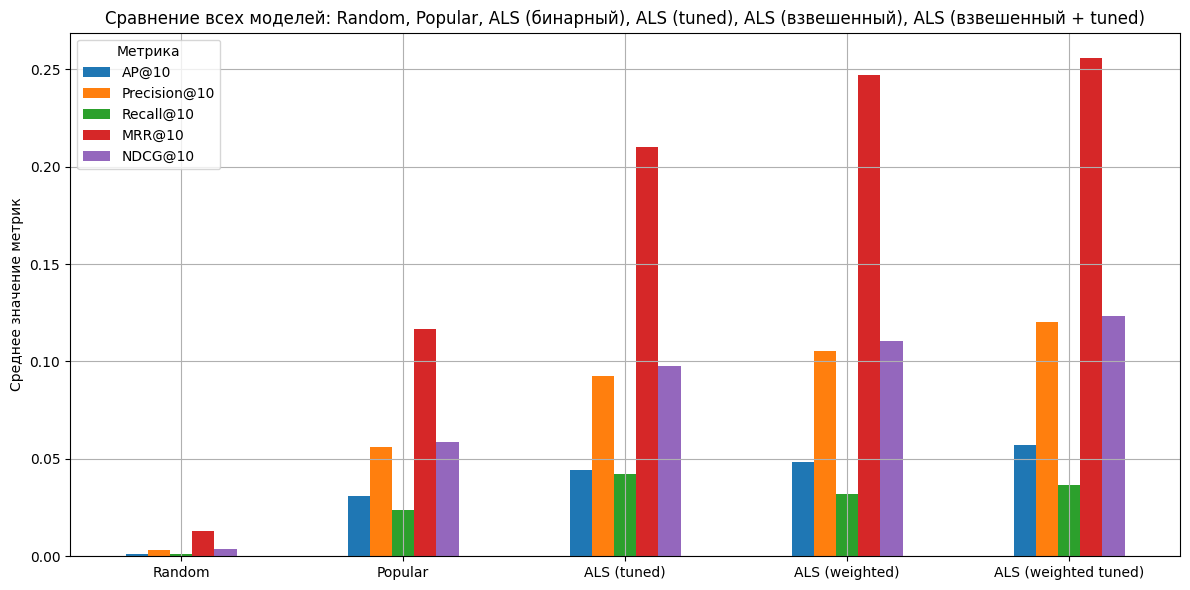

In [42]:
metrics_to_plot = ['AP@10', 'Precision@10', 'Recall@10', 'MRR@10', 'NDCG@10']

summary_df.loc[metrics_to_plot].T.plot(kind='bar', figsize=(12, 6))
plt.title('Сравнение всех моделей: Random, Popular, ALS (бинарный), ALS (tuned), ALS (взвешенный), ALS (взвешенный + tuned)')
plt.ylabel('Среднее значение метрик')
plt.xticks(rotation=0)
plt.grid(True)
plt.legend(title='Метрика')
plt.tight_layout()
plt.show()

In [43]:
summary_df.head(20)

,Random,Popular,ALS (tuned),ALS (weighted),ALS (weighted tuned)
user_id,27749.942000,27749.942000,NaN,NaN,NaN
AP@10,0.001276,0.030958,0.044436,0.048209,0.056995
Precision@10,0.003000,0.056000,0.092400,0.105200,0.120200
Recall@10,0.001270,0.023962,0.042420,0.031772,0.036709
MRR@10,0.012760,0.116781,0.210145,0.247134,0.256013
NDCG@10,0.003701,0.058536,0.097876,0.110710,0.123456


## Финальный вывод по модели ALS
В ходе эксперимента мы последовательно построили и проанализировали несколько моделей рекомендательной системы на основе метода матричной факторизации ALS (Alternating Least Squares), сравнив их с двумя бейзлайнами — случайным и популярным.
### Основные наблюдения:
Базовая модель ALS (tuned) уже существенно превосходит оба бейзлайна по всем метрикам, особенно по MRR и Precision@10.
Добавление весов на основе рейтингов (rating / 5) даёт заметный прирост качества, особенно в ранговых метриках (MRR, NDCG), а также в точности (Precision@10).
Финальный вариант — ALS (weighted tuned) показывает наилучшие результаты по 4 из 5 метрик, включая AP@10, Precision@10, MRR, NDCG, что говорит о максимально эффективной персонализации рекомендаций.
Интересно, что Recall@10 выше у ALS (tuned), что может быть связано с особенностями распределения весов и фильтрацией книг.

## Общий вывод
ALS (weighted tuned) — это оптимальный вариант модели на данном этапе. 
Она показывает, что:
персонализация работает,
веса улучшают представление о предпочтениях,
грамотный подбор параметров имеет решающее значение.
### Модель достигла:
AP@10 ≈ 0.057 (почти вдвое выше, чем у бейзлайна Popular),
Precision@10 ≈ 12%,
MRR ≈ 0.256

In [45]:
np.save(r"D:\ML\LS\Rec_sys_project\Collaborative_filtering\data\user_latent_vectors.npy", als_weighted_tuned.user_factors)
np.save(r"D:\ML\LS\Rec_sys_project\Collaborative_filtering\data\item_latent_vectors.npy", als_weighted_tuned.item_factors)
summary_df.to_csv(r"D:\ML\LS\Rec_sys_project\Collaborative_filtering\data\summary_metrics.csv")

with open(r"D:\ML\LS\Rec_sys_project\Collaborative_filtering\data\user_mapper.pkl", "wb") as f:
    pickle.dump(user_mapper, f)

with open(r"D:\ML\LS\Rec_sys_project\Collaborative_filtering\data\item_mapper.pkl", "wb") as f:
    pickle.dump(item_mapper, f)

user_features = train_df.groupby('user_id').agg(
    n_books=('book_id', 'count'),
    mean_rating=('rating', 'mean'),
    high_rating_share=('rating', lambda x: (x >= 4).mean())
).reset_index()
user_features.to_csv(r"D:\ML\LS\Rec_sys_project\Collaborative_filtering\data\user_features.csv", index=False)

In [7]:
summary_df = pd.read_csv(r"D:\ML\LS\Rec_sys_project\Collaborative_filtering\data\summary_metrics.csv", index_col=0)

## Bayesian Personalized Ranking

In [6]:
# Бинаризуем train_df
train_df_bpr = train_df.copy()
train_df_bpr['weight'] = 1.0

# Маппим индексы
train_user_index = train_df_bpr['user_id'].map(user_mapper)
train_item_index = train_df_bpr['book_id'].map(item_mapper)

# Собираем CSR-матрицу user × item
user_items_bpr = coo_matrix(
    (train_df_bpr['weight'], (train_user_index, train_item_index))
).tocsr()

print(f"BPR матрица: {user_items_bpr.shape[0]} users × {user_items_bpr.shape[1]} items")

BPR матрица: 53366 users × 9999 items


In [12]:
def evaluate_bpr_model(factors, regularization, iterations):
    model = BayesianPersonalizedRanking(
        factors=factors,
        regularization=regularization,
        iterations=iterations,
        random_state=42
    )
    model.fit(user_items_bpr)  # user × item матрица

    scores = []
    for user_id in tqdm(user_sample, desc="Evaluating BPR", leave=False):
        if user_id not in user_mapper:
            continue

        user_idx = user_mapper[user_id]
        seen = user_train_books.get(user_id, set())
        relevant_books = user_test_books.get(user_id, set())
        if not relevant_books:
            continue

        try:
            recs = model.recommend(
            user_idx,
            user_items_bpr[user_idx],
            N=10,
            filter_items=[item_mapper[b] for b in seen if b in item_mapper]
            )
            item_ids, _ = recs
            recommended_books = [
                item_inv[int(i)]
                for i in item_ids
                if int(i) in item_inv
            ]
            scores.append(ap_at_k(recommended_books, relevant_books))
        except Exception as e:
            print(f"User {user_id} error: {e}")
            continue

    return np.mean(scores)

In [13]:
def objective_bpr(trial):
    factors = trial.suggest_categorical('factors', [50, 100, 150])
    regularization = trial.suggest_float('regularization', 0.001, 0.1, log=True)
    iterations = trial.suggest_int('iterations', 10, 30)

    print(f"Trying: factors={factors}, reg={regularization:.5f}, iter={iterations}")
    score = evaluate_bpr_model(factors, regularization, iterations)
    print(f"mAP@10 = {score:.5f}")
    return score

In [14]:
study_bpr = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study_bpr.optimize(objective_bpr, n_trials=50, show_progress_bar=True)

print("\nЛучшие параметры (BPR):")
print(study_bpr.best_params)
print(f"mAP@10: {study_bpr.best_value:.5f}")

[I 2025-07-11 12:19:22,837] A new study created in memory with name: no-name-b875c9fc-6f94-41a2-8ee4-1b3233fbc64d


  0%|          | 0/50 [00:00<?, ?it/s]

Trying: factors=100, reg=0.01575, iter=13


  0%|          | 0/13 [00:00<?, ?it/s]

Evaluating BPR:   0%|          | 0/500 [00:00<?, ?it/s]

...

Evaluating BPR:   0%|          | 0/500 [00:00<?, ?it/s]

mAP@10 = 0.01439
[I 2025-07-11 12:27:24,883] Trial 48 finished with value: 0.014385952380952383 and parameters: {'factors': 150, 'regularization': 0.0988415749709003, 'iterations': 22}. Best is trial 29 with value: 0.0344781746031746.
Trying: factors=100, reg=0.00122, iter=28


  0%|          | 0/28 [00:00<?, ?it/s]

Evaluating BPR:   0%|          | 0/500 [00:00<?, ?it/s]

mAP@10 = 0.03381
[I 2025-07-11 12:27:36,132] Trial 49 finished with value: 0.033814841269841266 and parameters: {'factors': 100, 'regularization': 0.0012172756180824965, 'iterations': 28}. Best is trial 29 with value: 0.0344781746031746.

Лучшие параметры (BPR):
{'factors': 100, 'regularization': 0.0010107886651598008, 'iterations': 26}
mAP@10: 0.03448


In [16]:
# Извлекаем лучшие параметры
best_params_bpr = study_bpr.best_params

# Инициализация финальной модели
bpr_model = BayesianPersonalizedRanking(
    factors=best_params_bpr['factors'],
    regularization=best_params_bpr['regularization'],
    iterations=best_params_bpr['iterations'],
    random_state=42
)

# Обучение на user × item
bpr_model.fit(user_items_bpr)

# Сбор метрик
bpr_metrics = []

for user_id in tqdm(user_sample, desc="Evaluating BPR (tuned)"):
    if user_id not in user_mapper:
        continue

    user_idx = user_mapper[user_id]
    seen = user_train_books.get(user_id, set())
    relevant_books = user_test_books.get(user_id, set())
    if not relevant_books:
        continue

    try:
        recs = bpr_model.recommend(  # ← используем именно bpr_model
            user_idx,
            user_items_bpr[user_idx],
            N=10,
            filter_items=[item_mapper[b] for b in seen if b in item_mapper]
        )
        item_ids, _ = recs
        recommended_books = [
            item_inv[int(i)]
            for i in item_ids
            if int(i) in item_inv
        ]

        bpr_metrics.append({
            'user_id': user_id,
            'AP@10': ap_at_k(recommended_books, relevant_books),
            'Precision@10': precision_at_k(recommended_books, relevant_books),
            'Recall@10': recall_at_k(recommended_books, relevant_books),
            'MRR@10': mrr_at_k(recommended_books, relevant_books),
            'NDCG@10': ndcg_at_k(recommended_books, relevant_books)
        })
    except Exception as e:
        print(f"User {user_id} error: {e}")
        continue

  0%|          | 0/26 [00:00<?, ?it/s]

Evaluating BPR (tuned):   0%|          | 0/500 [00:00<?, ?it/s]

In [17]:
# Конвертируем в DataFrame
bpr_df = pd.DataFrame(bpr_metrics)

if not bpr_df.empty:
    mean_bpr = bpr_df.drop(columns='user_id').mean().rename('BPR (tuned)')
    summary_df = pd.concat([summary_df, mean_bpr], axis=1)
    print("Метрики BPR (tuned) добавлены.")
else:
    print("BPR метрики не собраны — пустой DataFrame.")

Метрики BPR (tuned) добавлены.


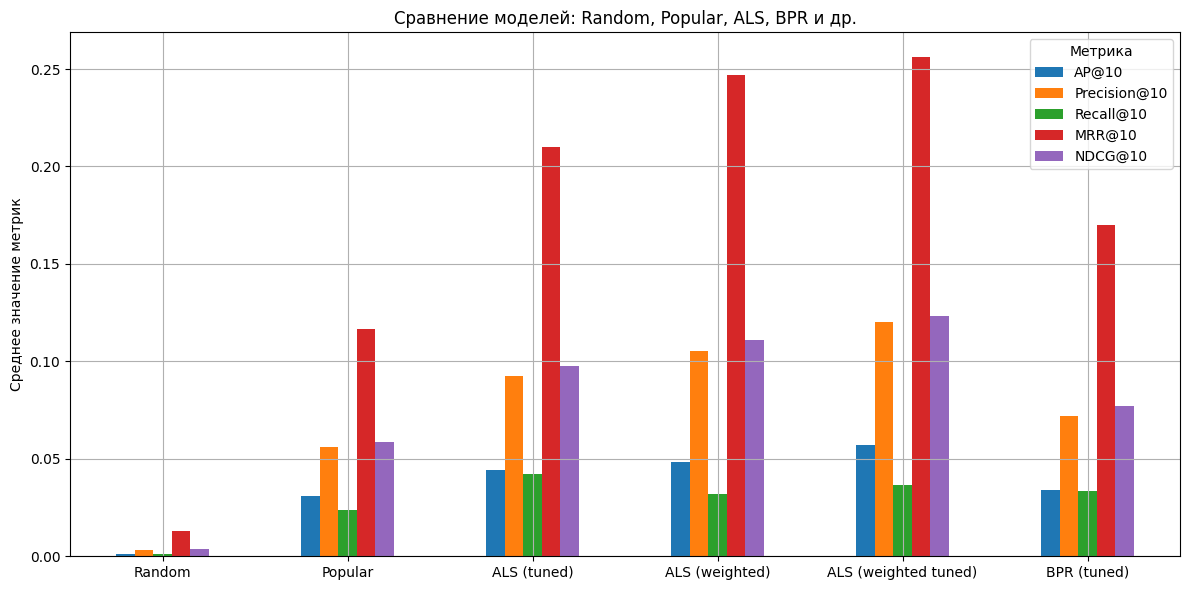

In [18]:
metrics_to_plot = ['AP@10', 'Precision@10', 'Recall@10', 'MRR@10', 'NDCG@10']

summary_df.loc[metrics_to_plot].T.plot(kind='bar', figsize=(12, 6))
plt.title('Сравнение моделей: Random, Popular, ALS, BPR и др.')
plt.ylabel('Среднее значение метрик')
plt.xticks(rotation=0)
plt.grid(True)
plt.legend(title='Метрика')
plt.tight_layout()
plt.show()

In [19]:
summary_df.head(50)

,Random,Popular,ALS (tuned),ALS (weighted),ALS (weighted tuned),BPR (tuned)
user_id,27749.942000,27749.942000,NaN,NaN,NaN,NaN
AP@10,0.001276,0.030958,0.044436,0.048209,0.056995,0.034254
Precision@10,0.003000,0.056000,0.092400,0.105200,0.120200,0.072000
Recall@10,0.001270,0.023962,0.042420,0.031772,0.036709,0.033668
MRR@10,0.012760,0.116781,0.210145,0.247134,0.256013,0.170124
NDCG@10,0.003701,0.058536,0.097876,0.110710,0.123456,0.077051


## LightFM

In [22]:
# Повторно используем бинаризированные данные
train_user_index = train_df['user_id'].map(user_mapper)
train_item_index = train_df['book_id'].map(item_mapper)

# Матрица взаимодействий: user × item
interactions = coo_matrix(
    (np.ones(len(train_df)), (train_user_index, train_item_index))
).tocsr()

In [23]:
def evaluate_lightfm_model(no_components, epochs, learning_rate):
    model = LightFM(
        no_components=no_components,
        loss='logistic',
        learning_rate=learning_rate,
        random_state=42
    )
    model.fit(interactions, epochs=epochs, verbose=False)

    scores = []
    for user_id in tqdm(user_sample, desc="Evaluating LightFM", leave=False):
        if user_id not in user_mapper:
            continue

        user_idx = user_mapper[user_id]
        seen = user_train_books.get(user_id, set())
        relevant_books = user_test_books.get(user_id, set())
        if not relevant_books:
            continue

        try:
            # Предсказание для всех книг
            scores_arr = model.predict(user_ids=user_idx, item_ids=np.arange(interactions.shape[1]))
            ranked_items = np.argsort(-scores_arr)  # по убыванию
            recommended_books = [
                item_inv[int(i)]
                for i in ranked_items
                if item_inv[int(i)] not in seen
            ][:10]

            scores.append(ap_at_k(recommended_books, relevant_books))
        except Exception as e:
            print(f"User {user_id} error: {e}")
            continue

    return np.mean(scores)

In [29]:
def objective_lightfm(trial):
    no_components = trial.suggest_categorical('no_components', [70, 100, 150])
    epochs = trial.suggest_int('epochs', 5, 10)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-1, log=True)

    print(f"Trying: components={no_components}, epochs={epochs}, lr={learning_rate:.5f}")
    score = evaluate_lightfm_model(no_components, epochs, learning_rate)
    print(f"mAP@10 = {score:.5f}")
    return score

study_lightfm = optuna.create_study(direction='maximize')
study_lightfm.optimize(objective_lightfm, n_trials=10, show_progress_bar=True)

print("\nЛучшие параметры (LightFM):")
print(study_lightfm.best_params)
print(f"mAP@10: {study_lightfm.best_value:.5f}")

[I 2025-07-11 13:46:41,657] A new study created in memory with name: no-name-81ec36ae-0345-4996-9e5d-f6ac0531aa6a


  0%|          | 0/10 [00:00<?, ?it/s]

Trying: components=70, epochs=5, lr=0.00374


Evaluating LightFM:   0%|          | 0/500 [00:00<?, ?it/s]

mAP@10 = 0.02945
[I 2025-07-11 13:49:08,237] Trial 0 finished with value: 0.029447063492063493 and parameters: {'no_components': 70, 'epochs': 5, 'learning_rate': 0.003742419242753255}. Best is trial 0 with value: 0.029447063492063493.
Trying: components=150, epochs=5, lr=0.01239


...

mAP@10 = 0.02937
[I 2025-07-11 14:28:21,935] Trial 7 finished with value: 0.029371825396825396 and parameters: {'no_components': 70, 'epochs': 6, 'learning_rate': 0.00044381398368413056}. Best is trial 5 with value: 0.02967984126984127.
Trying: components=150, epochs=5, lr=0.08303


Evaluating LightFM:   0%|          | 0/500 [00:00<?, ?it/s]

mAP@10 = 0.02957
[I 2025-07-11 14:33:28,631] Trial 8 finished with value: 0.029567619047619047 and parameters: {'no_components': 150, 'epochs': 5, 'learning_rate': 0.08302792356498424}. Best is trial 5 with value: 0.02967984126984127.
Trying: components=100, epochs=6, lr=0.00051


Evaluating LightFM:   0%|          | 0/500 [00:00<?, ?it/s]

mAP@10 = 0.02947
[I 2025-07-11 14:37:37,277] Trial 9 finished with value: 0.029470396825396827 and parameters: {'no_components': 100, 'epochs': 6, 'learning_rate': 0.000513005547841886}. Best is trial 5 with value: 0.02967984126984127.

Лучшие параметры (LightFM):
{'no_components': 70, 'epochs': 8, 'learning_rate': 0.07057075389729943}
mAP@10: 0.02968


In [30]:
# Извлекаем лучшие параметры
best_params_lfm = study_lightfm.best_params

# Финальная модель
lightfm_model = LightFM(
    no_components=best_params_lfm['no_components'],
    learning_rate=best_params_lfm['learning_rate'],
    loss='logistic',
    random_state=42
)
lightfm_model.fit(interactions, epochs=best_params_lfm['epochs'], verbose=True)

# Сбор метрик
lightfm_metrics = []

for user_id in tqdm(user_sample, desc="Evaluating LightFM (tuned)"):
    if user_id not in user_mapper:
        continue

    user_idx = user_mapper[user_id]
    seen = user_train_books.get(user_id, set())
    relevant_books = user_test_books.get(user_id, set())
    if not relevant_books:
        continue

    try:
        scores_arr = lightfm_model.predict(user_ids=user_idx, item_ids=np.arange(interactions.shape[1]))
        ranked_items = np.argsort(-scores_arr)
        recommended_books = [
            item_inv[int(i)]
            for i in ranked_items
            if item_inv[int(i)] not in seen
        ][:10]

        lightfm_metrics.append({
            'user_id': user_id,
            'AP@10': ap_at_k(recommended_books, relevant_books),
            'Precision@10': precision_at_k(recommended_books, relevant_books),
            'Recall@10': recall_at_k(recommended_books, relevant_books),
            'MRR@10': mrr_at_k(recommended_books, relevant_books),
            'NDCG@10': ndcg_at_k(recommended_books, relevant_books)
        })
    except Exception as e:
        print(f"User {user_id} error: {e}")
        continue

Epoch: 100%|██████████| 8/8 [03:45<00:00, 28.20s/it]


Evaluating LightFM (tuned):   0%|          | 0/500 [00:00<?, ?it/s]

In [31]:
lfm_df = pd.DataFrame(lightfm_metrics)

if not lfm_df.empty:
    mean_lfm = lfm_df.drop(columns='user_id').mean().rename('LightFM (logistic)')
    summary_df = pd.concat([summary_df, mean_lfm], axis=1)
    print("Метрики LightFM (logistic) добавлены.")
else:
    print("LightFM (logistic) метрики не собраны.")

Метрики LightFM (logistic) добавлены.


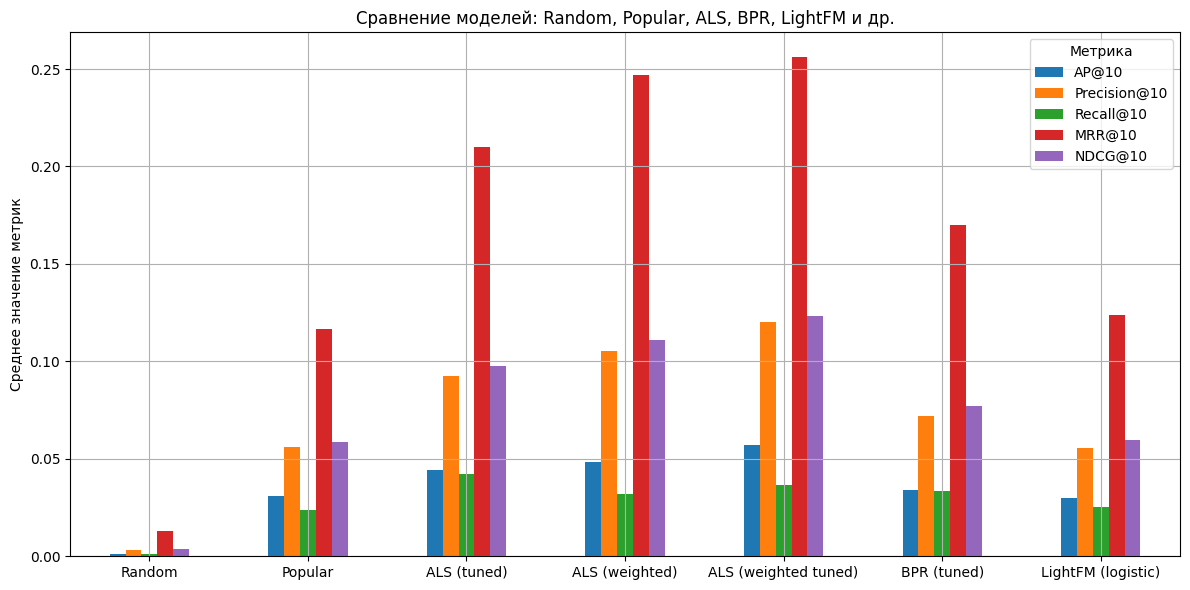

In [32]:
metrics_to_plot = ['AP@10', 'Precision@10', 'Recall@10', 'MRR@10', 'NDCG@10']

summary_df.loc[metrics_to_plot].T.plot(kind='bar', figsize=(12, 6))
plt.title('Сравнение моделей: Random, Popular, ALS, BPR, LightFM и др.')
plt.ylabel('Среднее значение метрик')
plt.xticks(rotation=0)
plt.grid(True)
plt.legend(title='Метрика')
plt.tight_layout()
plt.show()

In [33]:
summary_df.head(30)

,Random,Popular,ALS (tuned),ALS (weighted),ALS (weighted tuned),BPR (tuned),LightFM (logistic)
user_id,27749.942000,27749.942000,NaN,NaN,NaN,NaN,NaN
AP@10,0.001276,0.030958,0.044436,0.048209,0.056995,0.034254,0.029680
Precision@10,0.003000,0.056000,0.092400,0.105200,0.120200,0.072000,0.055800
Recall@10,0.001270,0.023962,0.042420,0.031772,0.036709,0.033668,0.025442
MRR@10,0.012760,0.116781,0.210145,0.247134,0.256013,0.170124,0.123879
NDCG@10,0.003701,0.058536,0.097876,0.110710,0.123456,0.077051,0.059463


In [34]:
summary_df.to_csv(r"D:\ML\LS\Rec_sys_project\Collaborative_filtering\data\summary_metrics.csv")
print("summary_df сохранён.")

summary_df сохранён.


## Промежуточный вывод по моделям коллаборативной фильтрации
### Цель эксперимента:
Оценить и сравнить три основных метода:
ALS (Alternating Least Squares)
BPR (Bayesian Personalized Ranking)
LightFM (Logistic MF)
по следующим критериям:
метрики качества (AP@10, Precision@10, MRR и др.)
время обучения
реалистичность применения в финальном гибридном проекте

## Краткий анализ:
### ALS
Лучшая модель по всем метрикам
Очень быстро обучается
Легко настраивается через alpha, factors, iterations
Подходит как основа коллаборативной части в гибридной системе

### BPR
Специализируется на ранговых задачах
Лучше работает по MRR, чем LightFM
Хорошее качество + быстрое обучение
Можно использовать в ансамбле или как альтернатива ALS

### LightFM
Уступает по всем метрикам ALS и BPR
Очень долго обучается без OpenMP
Потенциал проявляется при использовании side features (жанры, описания и др.)
В текущем виде — бенчмарк, но не основная модель

## Идеи и выводы:
Для финальной гибридной системы основной ставкой остаётся ALS (weighted tuned);
BPR может быть использован как дополнительная модель в ансамбле;
LightFM — при наличии фичей (жанры, описания) или для дополнительных эмбеддингов;
Следующий логичный шаг — кластеризация пользователей по ALS-векторам, чтобы строить модели с учётом сегментов.

## Эксперимент по кластеризации

## Цель:
Кластеризовать пользователей по ALS-векторам, чтобы:
выявить поведенческие паттерны
обучать отдельные модели внутри кластеров
возможно, получить лучшие рекомендации через сегментированные модели

In [36]:
# Загрузка векторов пользователей
user_factors = np.load(r"D:\ML\LS\Rec_sys_project\Collaborative_filtering\data\user_latent_vectors.npy")

# Количество кластеров — укажи после анализа silhouette score
optimal_n_clusters = 5  

# Кластеризация
kmeans = KMeans(n_clusters=optimal_n_clusters, random_state=42, n_init=10)
user_cluster_labels = kmeans.fit_predict(user_factors)

# Сохраняем кластерные метки
np.save(r"D:\ML\LS\Rec_sys_project\Collaborative_filtering\data\user_clusters.npy", user_cluster_labels)

# (опционально) сохранить сам kmeans-модель, если понадобится
with open(r"D:\ML\LS\Rec_sys_project\Collaborative_filtering\data\kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

print(f"Кластеризация завершена. Метки для {len(user_cluster_labels)} пользователей сохранены.")

Кластеризация завершена. Метки для 53424 пользователей сохранены.


In [37]:
# Загрузка user_id ↔ index маппера
with open(r"D:\ML\LS\Rec_sys_project\Collaborative_filtering\data\user_mapper.pkl", "rb") as f:
    user_mapper = pickle.load(f)

user_inv = {v: k for k, v in user_mapper.items()}

# Загрузка кластеров и фичей
cluster_labels = np.load(r"D:\ML\LS\Rec_sys_project\Collaborative_filtering\data\user_clusters.npy")
user_features = pd.read_csv(r"D:\ML\LS\Rec_sys_project\Collaborative_filtering\data\user_features.csv")

# Преобразуем индексы кластеров обратно в user_id
cluster_df = pd.DataFrame({
    "user_index": range(len(cluster_labels)),
    "cluster": cluster_labels
})
cluster_df["user_id"] = cluster_df["user_index"].map(user_inv)

# Объединяем с фичами
merged = pd.merge(user_features, cluster_df[["user_id", "cluster"]], on="user_id", how="inner")

# Сохраняем объединённый файл
merged.to_csv(r"D:\ML\LS\Rec_sys_project\Collaborative_filtering\data\user_features_with_clusters.csv", index=False)
print("Файл с кластерными метками сохранён.")

Файл с кластерными метками сохранён.


C:\Users\555\AppData\Local\Temp\ipykernel_16008\156822671.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster', data=user_cluster_df, palette='Set2')


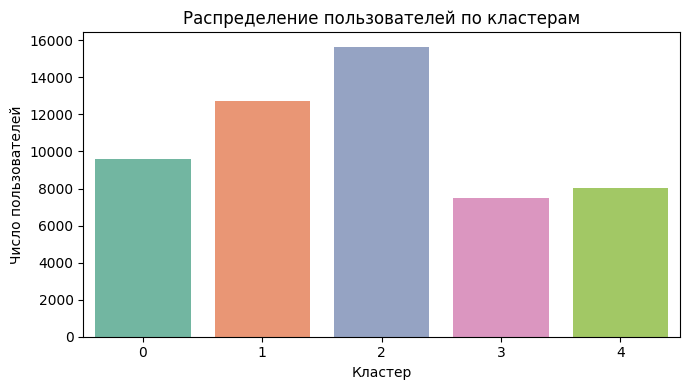

C:\Users\555\AppData\Local\Temp\ipykernel_16008\156822671.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='n_books', data=user_cluster_df, palette='Set3')


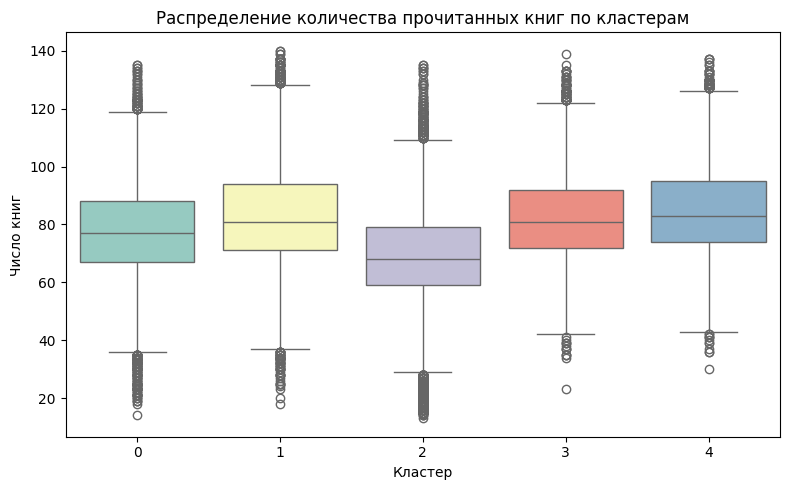

C:\Users\555\AppData\Local\Temp\ipykernel_16008\156822671.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='mean_rating', data=user_cluster_df, palette='Set1')


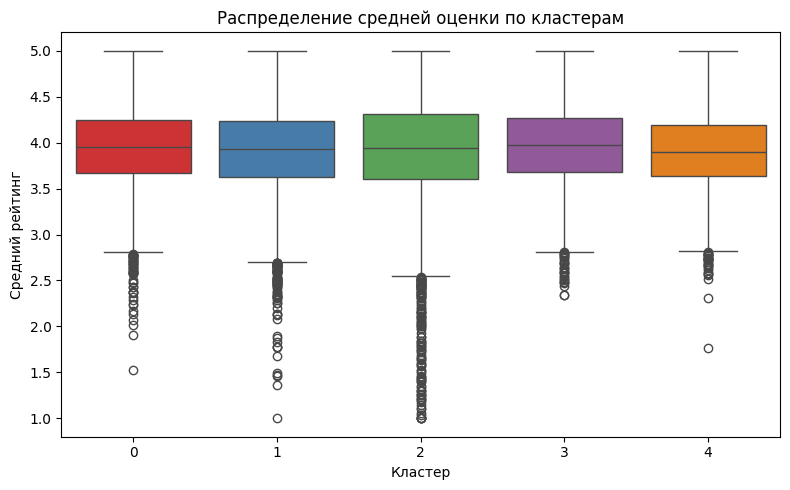

C:\Users\555\AppData\Local\Temp\ipykernel_16008\156822671.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='high_rating_share', data=user_cluster_df, palette='Set2')


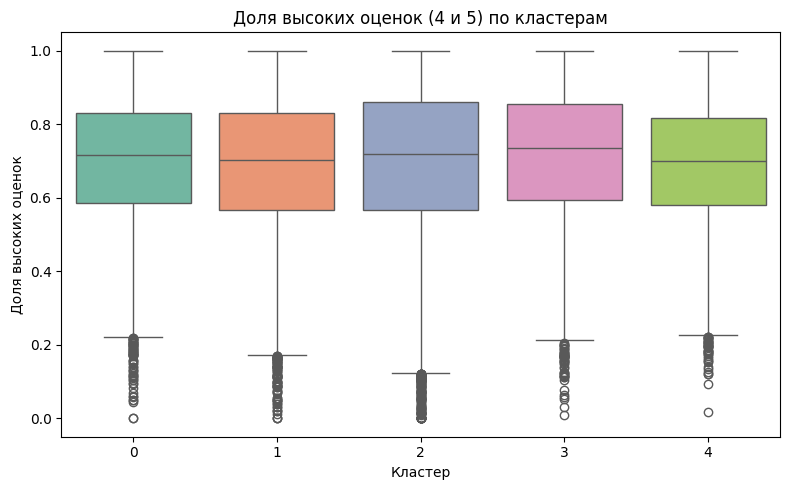

In [38]:
# Загружаем файл
user_cluster_df = pd.read_csv(r"D:\ML\LS\Rec_sys_project\Collaborative_filtering\data\user_features_with_clusters.csv")

# Распределение пользователей по кластерам
plt.figure(figsize=(7, 4))
sns.countplot(x='cluster', data=user_cluster_df, palette='Set2')
plt.title("Распределение пользователей по кластерам")
plt.xlabel("Кластер")
plt.ylabel("Число пользователей")
plt.tight_layout()
plt.show()

# Количество книг на пользователя
plt.figure(figsize=(8, 5))
sns.boxplot(x='cluster', y='n_books', data=user_cluster_df, palette='Set3')
plt.title("Распределение количества прочитанных книг по кластерам")
plt.xlabel("Кластер")
plt.ylabel("Число книг")
plt.tight_layout()
plt.show()

# Средний рейтинг пользователя
plt.figure(figsize=(8, 5))
sns.boxplot(x='cluster', y='mean_rating', data=user_cluster_df, palette='Set1')
plt.title("Распределение средней оценки по кластерам")
plt.xlabel("Кластер")
plt.ylabel("Средний рейтинг")
plt.tight_layout()
plt.show()

# Доля высоких оценок (4 и 5)
plt.figure(figsize=(8, 5))
sns.boxplot(x='cluster', y='high_rating_share', data=user_cluster_df, palette='Set2')
plt.title("Доля высоких оценок (4 и 5) по кластерам")
plt.xlabel("Кластер")
plt.ylabel("Доля высоких оценок")
plt.tight_layout()
plt.show()

In [39]:
# Агрегация по кластерам
cluster_stats = user_cluster_df.groupby("cluster").agg(
    users_count=('user_id', 'count'),
    avg_books=('n_books', 'mean'),
    avg_rating=('mean_rating', 'mean'),
    avg_high_rating_share=('high_rating_share', 'mean')
).round(3).reset_index()

# Сохранение в CSV (чтобы загрузить мне)
cluster_stats.to_csv(r"D:\ML\LS\Rec_sys_project\Collaborative_filtering\data\cluster_stats.csv", index=False)

# Просмотр
print(cluster_stats)

   cluster  users_count  avg_books  avg_rating  avg_high_rating_share
0        0         9575     77.694       3.952                  0.700
1        1        12706     82.941       3.928                  0.689
2        2        15650     68.084       3.946                  0.698
3        3         7466     82.342       3.975                  0.713
4        4         8027     84.903       3.915                  0.690


## Вывод по кластеризации пользователей
В рамках эксперимента с кластеризацией мы:
Провели кластеризацию пользователей по их ALS-векторам (latent-факторам).
Получили 5 кластеров (на текущем этапе выбраны эвристически).
Сопоставили каждому пользователю следующие признаки:
cluster_id — принадлежность к кластеру;
n_books — количество прочитанных книг;
mean_rating — средняя оценка пользователя;
high_rating_share — доля оценок 4 и 5.

## Анализ различий между кластерами
Отличия между кластерами умеренные, но заметны в активности пользователей и доле высоких оценок. Это может оказаться полезным при дальнейшем построении персонализированных моделей.

## Как мы будем использовать кластеризацию
Сохранили cluster_id как категориальный признак, который можно передавать в табличные модели (например, TabNet, MLP, CatBoost);
Подготовили датафрейм user_features_with_clusters.csv с полными признаками для каждого пользователя;
Планируем использовать эти фичи в гибридной рекомендательной системе совместно с эмбеддингами и признаками книг.